# Chromosome, Replicate 1 Scripting

Create a script to run the deconvolution on each replicate. This notebook will test the script.


In [119]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [120]:
from pipeline.fit_replication_profiles import main
from src.utils import mkdir_safe

output_directory = "output/prototype_pipeline_subset_stage2/"


In [157]:
from pipeline.fit_replication_profiles import main as fit_replication_profile
from src.utils import print_fl
from src.config import load_default_chrom_configs, load_cloccs_configs
from src.RealDataReplication import RealDataReplicationDeconvolution
from src.optimize_H import create_bounds_params_from_config

cold_start = False
chrom = 4
replicate = 1
num_epochs = 1
config = None
config, _ = load_cloccs_configs(shift_CLOCCS=False)

np.random.seed(123)

update_params_df, replication_deconvolver, optimizer = fit_replication_profile(chrom=chrom, 
    replicate=replicate, num_epochs=num_epochs, output_directory=output_directory, 
    save=False, config=config,
    learn_subset_parameters=['mu0', 'sigma0', 'gamma2'])

Loading MNase data
Omit windows with less than 75% read coverage.
Running initial iterations...
Deconvolving 702 regions
Initializing B using timepoint 0
Subsetting the cell cycle parameters to learn:  ['mu0', 'sigma0', 'gamma2']
[0] 00:00:00.164, rn=0.033393455802475935
[1] 00:00:00.325, rn=0.005394224883929299
[2] 00:00:00.487, rn=0.004932828385065331
[3] 00:00:00.645, rn=0.004601944250729742
[4] 00:00:00.813, rn=0.004392169254585151
[5] 00:00:00.972, rn=0.004280782112474945
[6] 00:00:01.141, rn=0.00422241652860931
[7] 00:00:01.306, rn=0.004192732668871569
[8] 00:00:01.471, rn=0.004175624748525048
[9] 00:00:01.636, rn=0.0041642180718704114
[10] 00:00:01.796, rn=0.004158777345353125
[11] 00:00:01.954, rn=0.004155868053904873
[12] 00:00:02.115, rn=0.004155024964001808
[13] 00:00:02.283, rn=0.004154563978198053
[14] 00:00:02.449, rn=0.004154560993364367
[15] 00:00:02.608, rn=0.004154560991811165
[16] 00:00:02.767, rn=0.004154560991810427
[17] 00:00:02.927, rn=0.004154560991810427
[18] 0

In [163]:
replication_deconvolver.save_to_disk('output/draft1_run/')

Creating directory: output/draft1_run/...Directory exists. Skipping.
Dictionary saved to output/draft1_run//single_replication/rep1.json
Saved to : output/draft1_run//single_replication/rep1.json
Saved to: output/draft1_run//rep1_chr4_N.npy
Saved to: output/draft1_run//rep1_chr4_B.csv
Saved to: output/draft1_run//rep1_chr4_H.npy
Saved to: output/draft1_run//rep1_chr4_F.csv
Saved to: output/draft1_run//rep1_chr4_G.csv
Saved to: output/draft1_run//rep1_chr4_parameters.csv
Saved to: output/draft1_run//rep1_chr4.png


In [158]:
replication_deconvolver.iterative_deconvolution_updates(20)

[0] 00:00:00.204, rn=0.031953891549862334
[1] 00:00:00.364, rn=0.005226115937687033
[2] 00:00:00.524, rn=0.00470255053324862
[3] 00:00:00.684, rn=0.004349132606853981
[4] 00:00:00.843, rn=0.004146313605030658
[5] 00:00:01.074, rn=0.004045439806046934
[6] 00:00:01.252, rn=0.003994461864387493
[7] 00:00:01.414, rn=0.003967884518179178
[8] 00:00:01.581, rn=0.00395570090918717
[9] 00:00:01.739, rn=0.003950599505734834
[10] 00:00:01.900, rn=0.003947072599741859
[11] 00:00:02.059, rn=0.003946677074666966
[12] 00:00:02.220, rn=0.003946343746121751
[13] 00:00:02.440, rn=0.00394633021892701
[14] 00:00:02.603, rn=0.00394633021633164
[15] 00:00:02.771, rn=0.003946330216330798
[16] 00:00:02.930, rn=0.0039463302163307975
[17] 00:00:03.090, rn=0.0039463302163307975
[18] 00:00:03.252, rn=0.0039463302163307975
[19] 00:00:03.394, rn=0.0039463302163307975


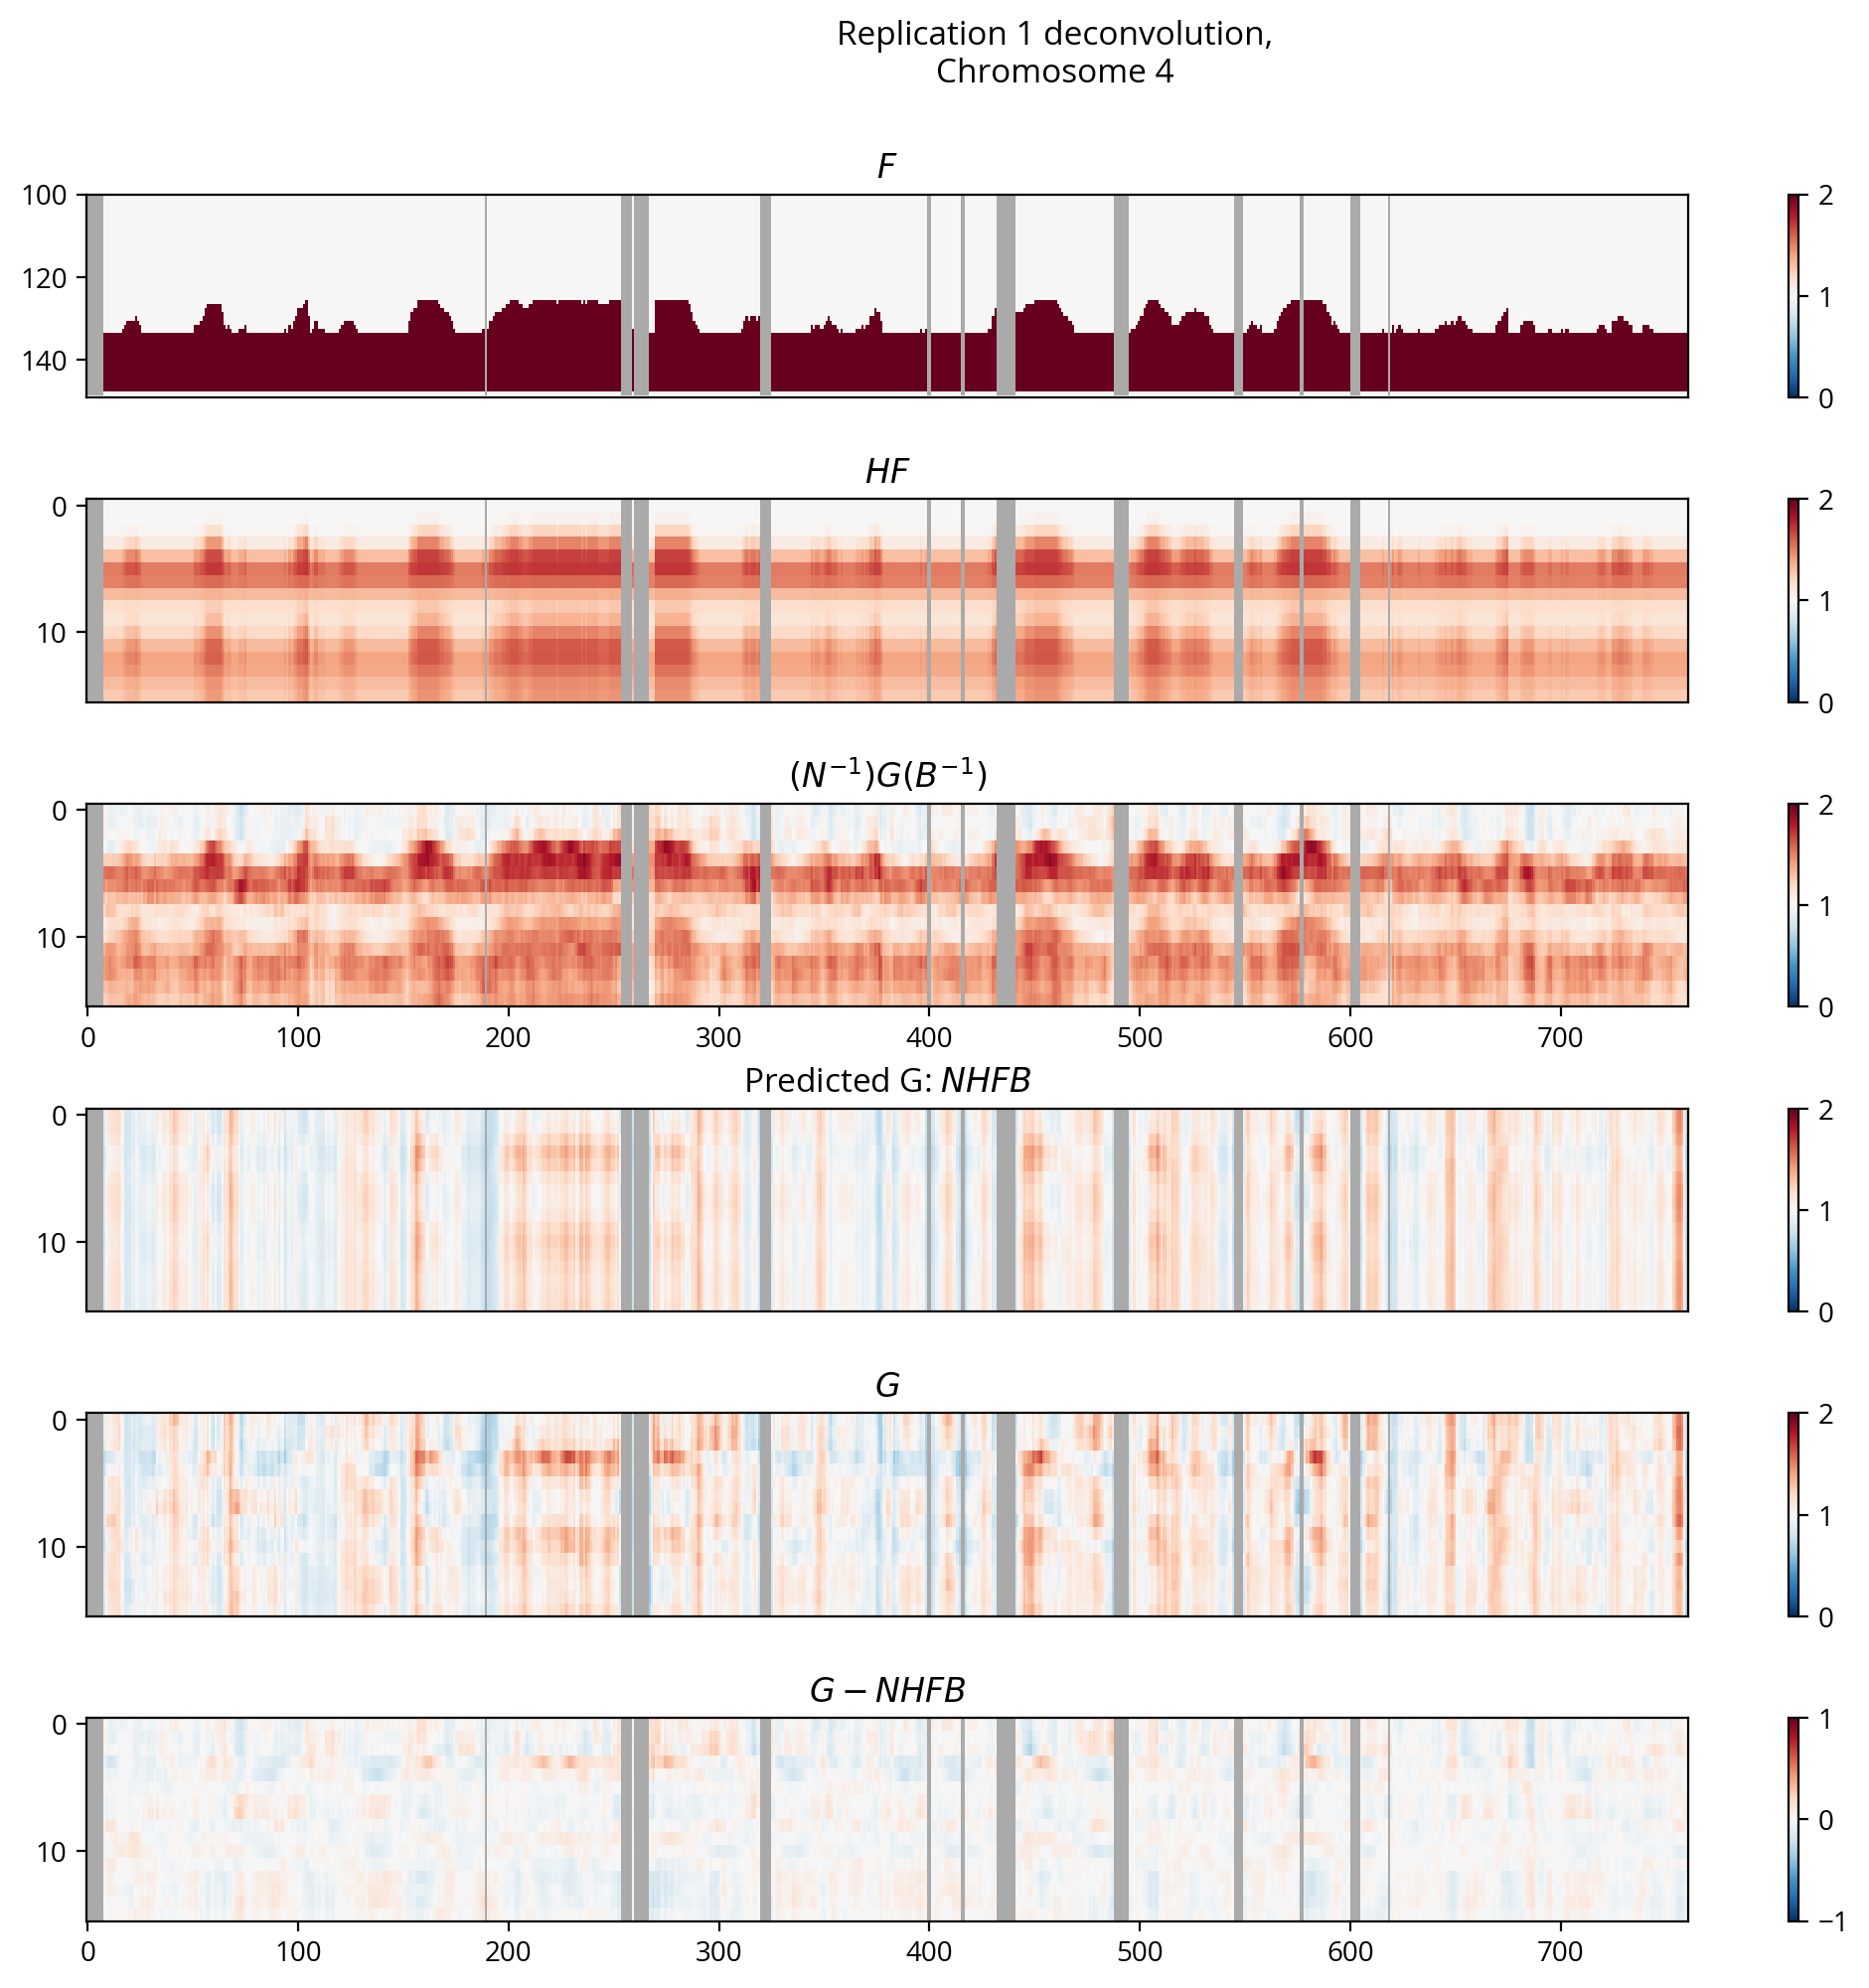

In [159]:
fig = replication_deconvolver.plot_heatmaps()